In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '12'
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve
import shap
import joblib
import os


In [2]:
#Load Data

Data_path= (r"C:\Users\Sarika\Downloads\customer\Telco_customer_churn.xlsx")
df= pd.read_excel(Data_path)

print(f"1.Shape: {df.shape}")
print(f"2.First 5 rows:{ df.head(5)}")
print(f"3.Column: {df.columns}")
print(f"4.Customer Duplicated Value : {df.duplicated().sum()}")
df.info()
print(f"5.Categorical Unique Values:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")


1.Shape: (7043, 33)
2.First 5 rows:   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             P

1.Basic Stata
        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000000     5.000000  2003.000000  
25%          35.5

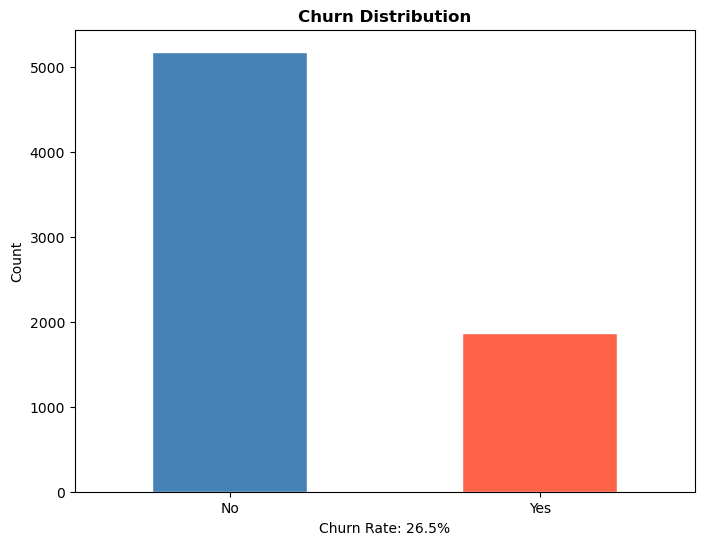

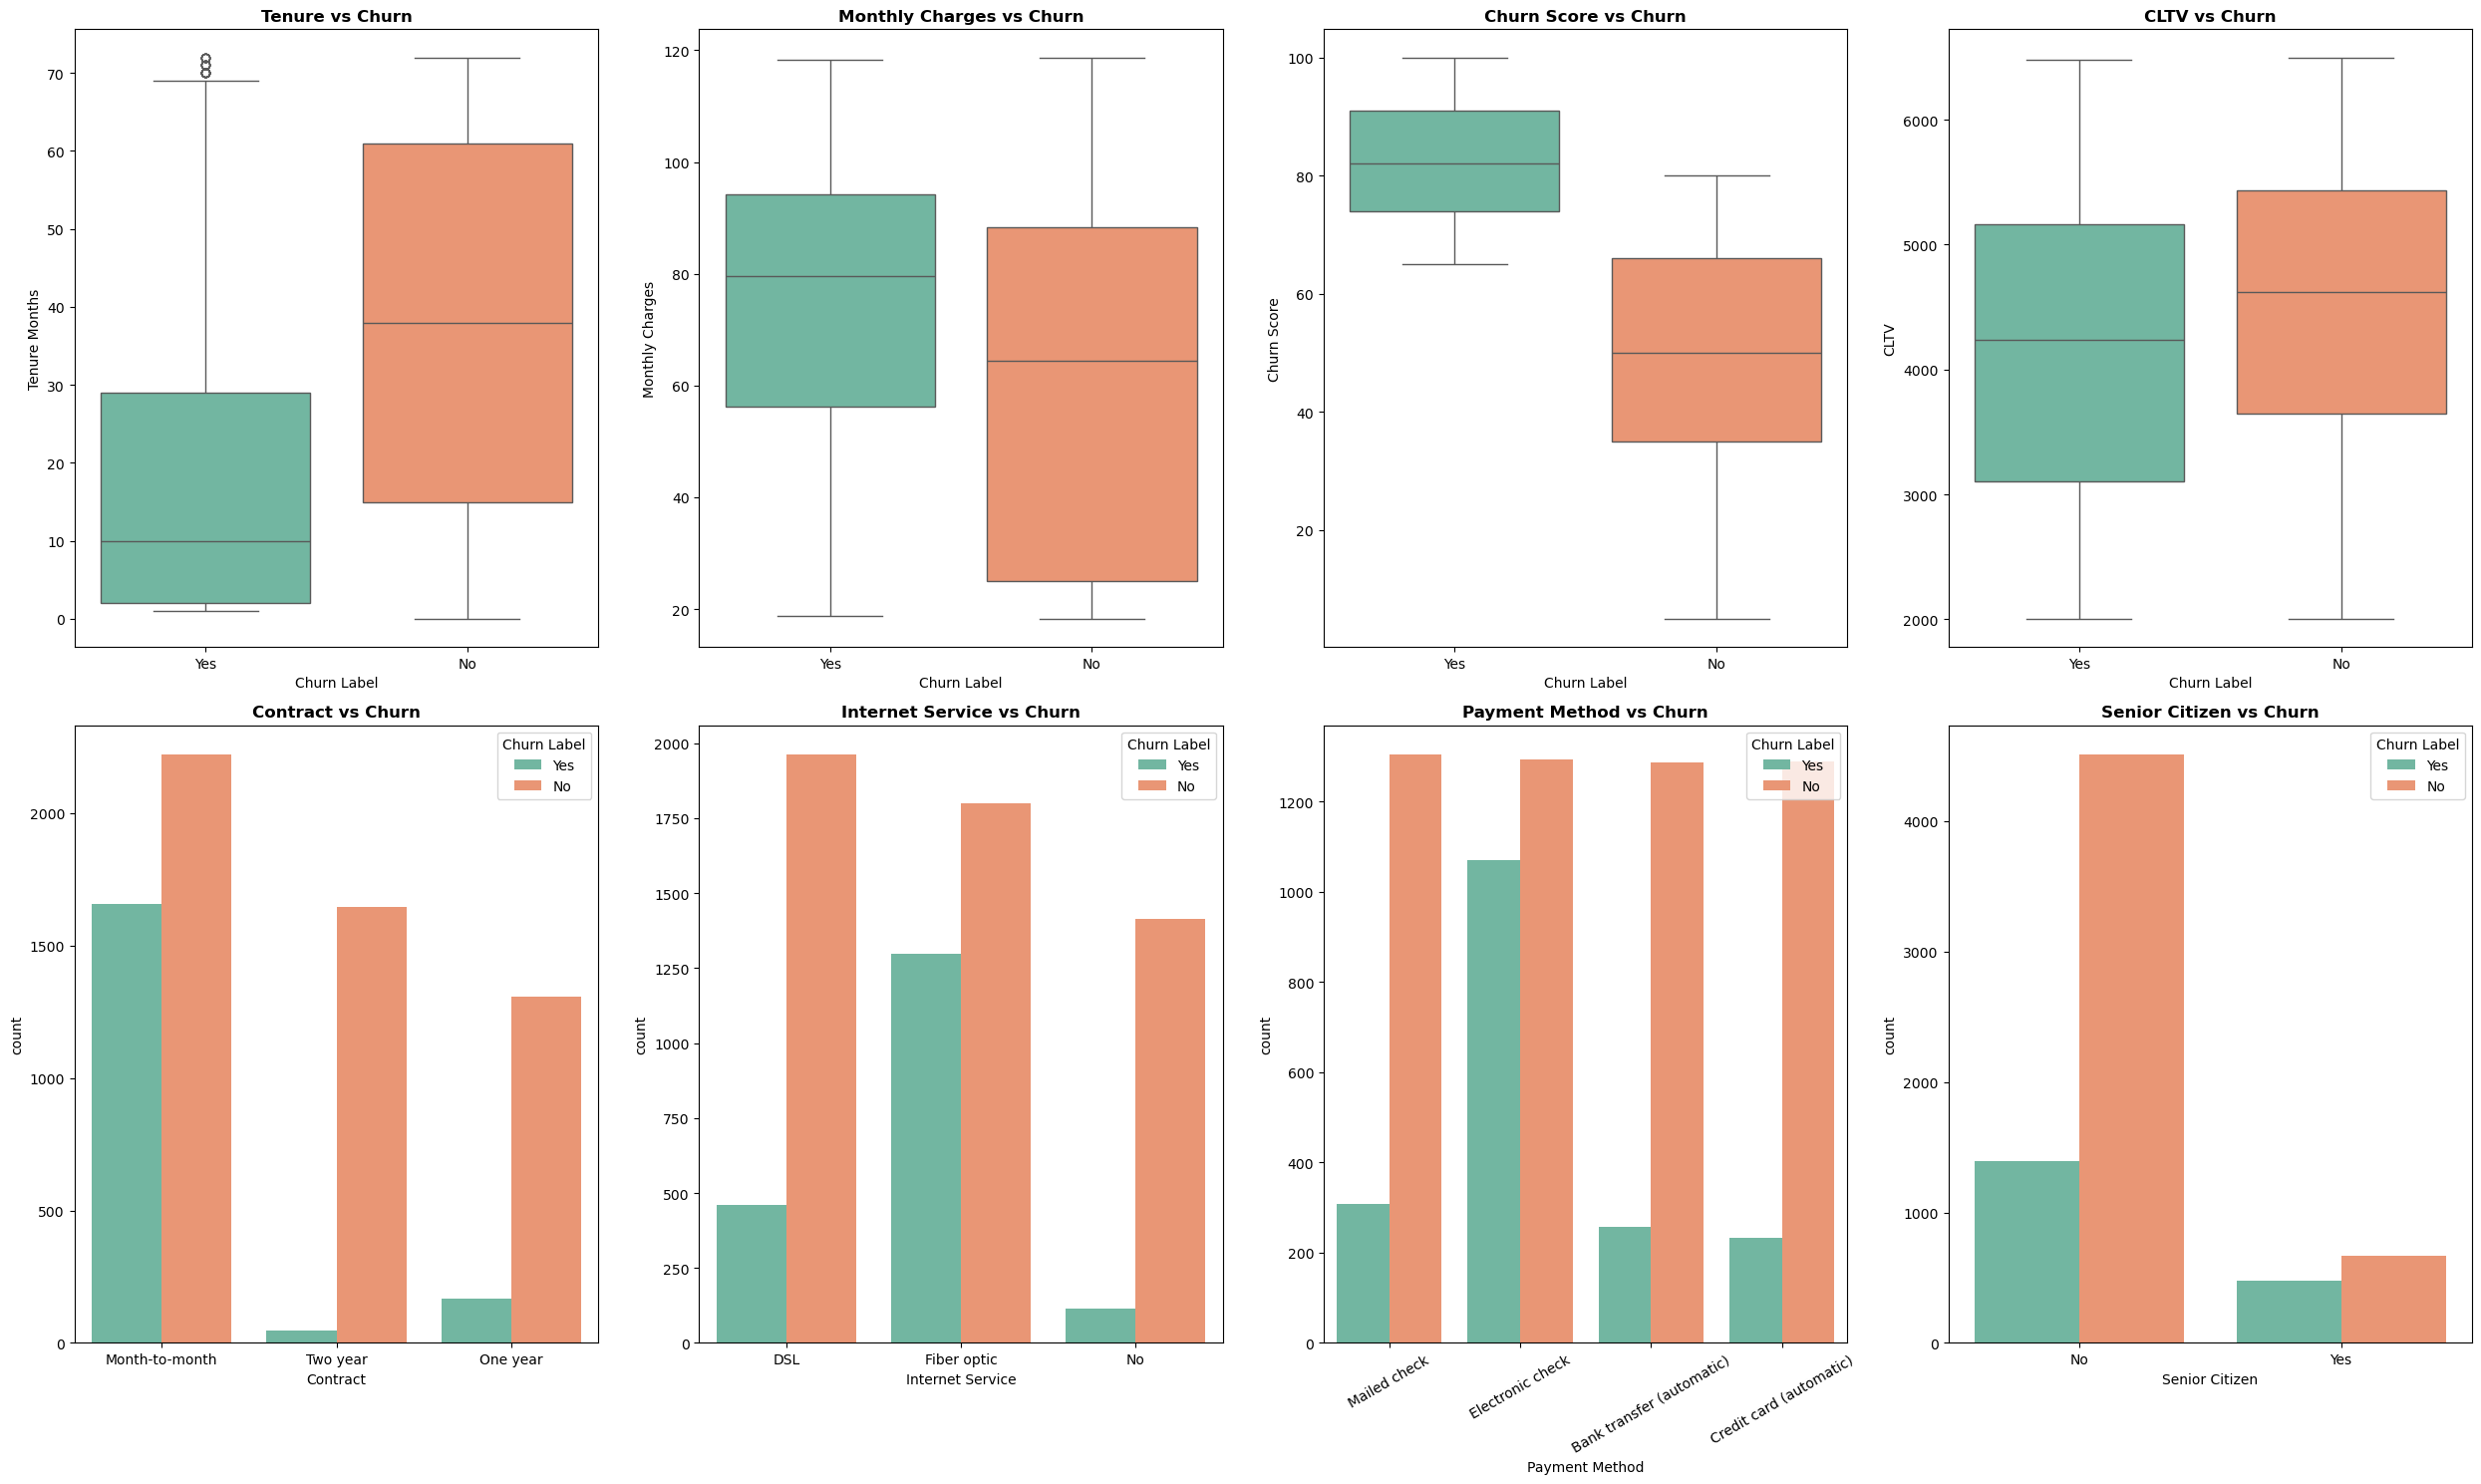

In [3]:
print("1.Basic Stata")
print(df.describe())
print("2.Numeric correlation with churn")
print(df.select_dtypes(include='number').drop(columns=['Count'], errors='ignore').corrwith(df['Churn Value']).sort_values(ascending=False))
print("3.Category unique count" )
print(df.select_dtypes(include='object').nunique())

#visualize
plt.figure(figsize=(8, 6))
df['Churn Label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Churn Distribution', fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Count')
churn_rate = df['Churn Label'].value_counts(normalize=True)['Yes'] * 100
plt.xlabel(f'Churn Rate: {churn_rate:.1f}%')
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


fig ,axes= plt.subplots(2,4 , figsize=(25,15))

sns.boxplot(data=df, x='Churn Label' , y='Tenure Months' , hue='Churn Label', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Tenure vs Churn', fontweight='bold')

sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', hue='Churn Label', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Monthly Charges vs Churn', fontweight='bold')

sns.boxplot(data=df, x='Churn Label', y='Churn Score', hue='Churn Label', ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Churn Score vs Churn', fontweight='bold')

sns.boxplot(data=df, x='Churn Label', y='CLTV', hue='Churn Label', ax=axes[0,3], palette='Set2')
axes[0,3].set_title('CLTV vs Churn', fontweight='bold')

sns.countplot(data=df, x='Contract', hue='Churn Label', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Contract vs Churn', fontweight='bold')

sns.countplot(data=df, x='Internet Service', hue='Churn Label', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Internet Service vs Churn', fontweight='bold')

sns.countplot(data=df, x='Payment Method', hue='Churn Label', ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Payment Method vs Churn', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='Senior Citizen', hue='Churn Label', ax=axes[1,3], palette='Set2')
axes[1,3].set_title('Senior Citizen vs Churn', fontweight='bold')

plt.tight_layout()

plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Clean & Create df_ml(Feature Engineering)

# Fix Total Charges dtype
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# Drop useless columns
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 
             'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 
             'Churn Reason', 'Churn Label', 'Churn Score']
df_ml = df.drop(columns=drop_cols, errors='ignore')

# Encode binary categoricals
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing']
for col in binary_cols:
    df_ml[col] = (df_ml[col] == 'Yes').astype(int)

# Fix Gender separately (Male/Female not Yes/No)
df_ml['Gender'] = (df['Gender'] == 'Male').astype(int)

# Encode multi-category columns
df_ml = pd.get_dummies(df_ml, columns=['Multiple Lines', 'Internet Service',
                                        'Online Security', 'Online Backup',
                                        'Device Protection', 'Tech Support',
                                        'Streaming TV', 'Streaming Movies',
                                        'Contract', 'Payment Method'], drop_first=True)

#converting bools into int
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

X = df_ml.drop(columns=['Churn Value'])
y = df_ml['Churn Value']

# Score each feature
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)

# Show ranked features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print(feature_scores)

df_ml.drop(columns=['Gender', 'Phone Service', 'Multiple Lines_No phone service' ],inplace=True)
print(f"Shape: {df_ml.shape}")
print(f"Dtypes:\n{df_ml.dtypes}")

print(f"Final df_ml shape: {df_ml.shape}")
print(df_ml.dtypes)

                                   Feature       Score
4                            Tenure Months  997.268010
12            Internet Service_Fiber optic  738.046042
27                       Contract_Two year  707.919254
29         Payment Method_Electronic check  706.195028
3                               Dependents  463.582354
13                     Internet Service_No  385.698588
14     Online Security_No internet service  385.698588
18   Device Protection_No internet service  385.698588
20        Tech Support_No internet service  385.698588
24    Streaming Movies_No internet service  385.698588
22        Streaming TV_No internet service  385.698588
16       Online Backup_No internet service  385.698588
8                            Total Charges  290.439831
7                          Monthly Charges  273.463704
6                        Paperless Billing  268.985218
26                       Contract_One year  229.905741
15                     Online Security_Yes  212.666199
21        

  File "C:\Users\Sarika\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Sarika\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sarika\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sarika\anaconda3\Lib\subproc

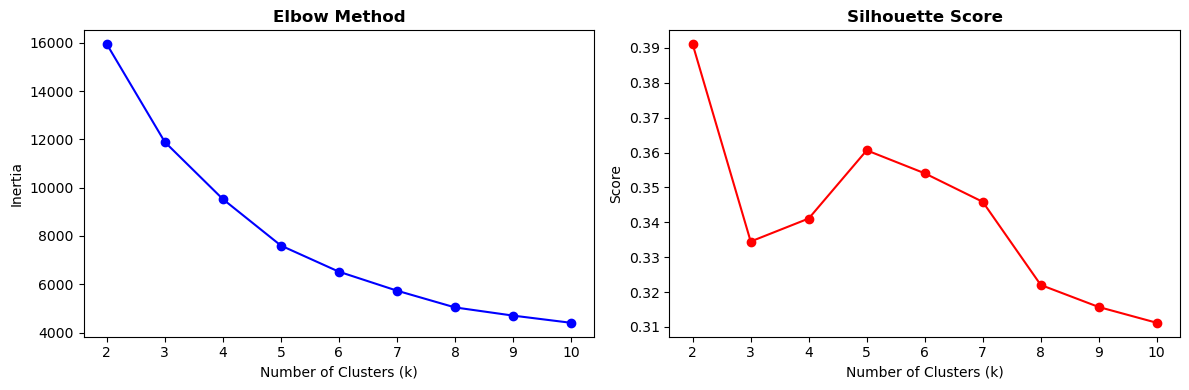


Silhouette Scores:
k=2: 0.3911
k=3: 0.3345
k=4: 0.3411
k=5: 0.3607
k=6: 0.3541
k=7: 0.3459
k=8: 0.3220
k=9: 0.3157
k=10: 0.3112
         Tenure Months  Monthly Charges  Total Charges     CLTV  Churn Value
Segment                                                                     
0                59.19            93.19        5506.53  5100.52         0.16
1                11.04            57.69         689.46  4972.25         0.39
2                17.55            61.05        1105.81  2940.77         0.35
3                54.52            32.43        1763.31  5101.30         0.04
Segment_Name
Mid Value At-Risk    2168
New At-Risk          1950
High Value Loyal     1916
Budget Loyal         1009
Name: count, dtype: int64


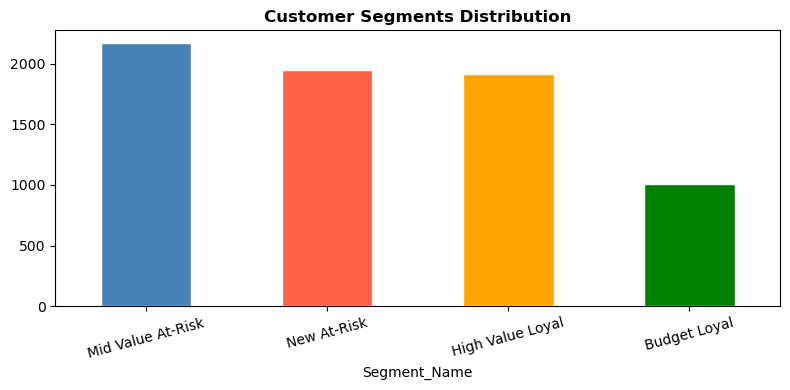

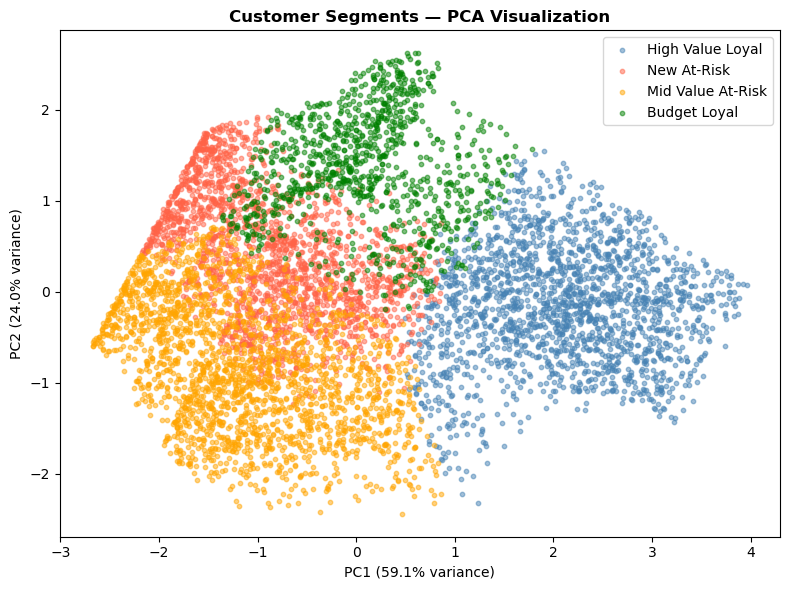

In [5]:
#clustering
# Use only meaningful numeric columns for clusteringcluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
X_cluster = df_ml[cluster_features].copy()

# Scale — important for KMeans, it's distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow + Silhouette to find optimal K
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 11), inertias, 'bo-')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 11), silhouette_scores, 'ro-')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['Segment'] = kmeans.fit_predict(X_scaled)

# Profile each segment
print(df_ml.groupby('Segment')[cluster_features + ['Churn Value']].mean().round(2))

segment_names = {
    0: 'High Value Loyal',
    1: 'New At-Risk',
    2: 'Mid Value At-Risk',
    3: 'Budget Loyal'
}
df_ml['Segment_Name'] = df_ml['Segment'].map(segment_names)

# Distribution
print(df_ml['Segment_Name'].value_counts())

# Visualize
plt.figure(figsize=(8, 4))
df_ml['Segment_Name'].value_counts().plot(kind='bar', color=['steelblue','tomato','orange','green'], edgecolor='white')
plt.title('Customer Segments Distribution', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('segments.png', dpi=150, bbox_inches='tight')
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'orange', 'green']
for i, name in segment_names.items():
    mask = df_ml['Segment'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], label=name, alpha=0.5, s=10)

plt.title('Customer Segments — PCA Visualization', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig('pca_segments.png', dpi=150, bbox_inches='tight')
plt.show()

------------------------------------------------------------
Logistic Regression
Test AUC: 0.8466 | CV AUC: 0.8555
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

------------------------------------------------------------
XGBoost
Test AUC: 0.8310 | CV AUC: 0.8293
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.69      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

------------------------------------------------------------
Random Forest
Test AUC: 0.8364 | CV AUC: 0.8386
              preci

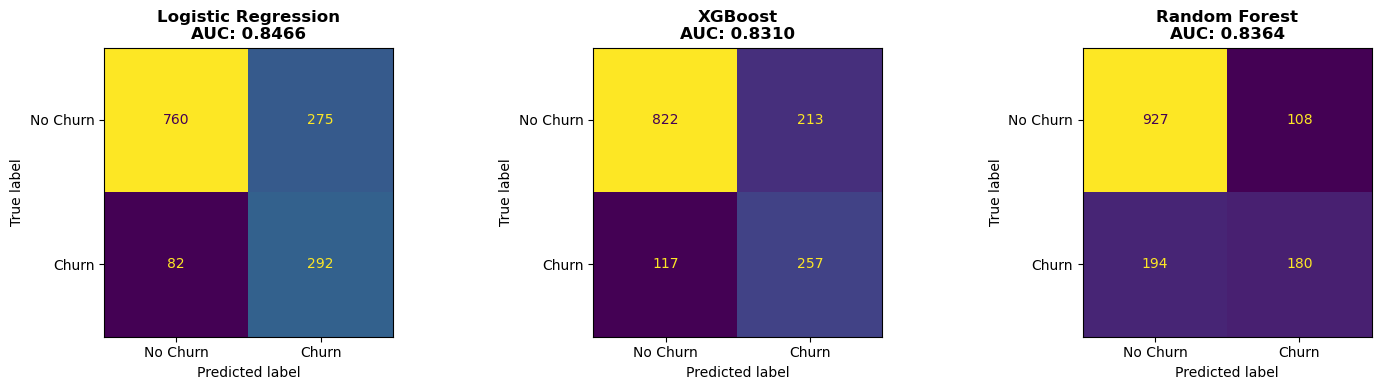

------------------------------------------------------------
ROUND 1 — Class Weight (threshold=0.5)
Model                  AUC      Recall   Precision  F1      
Logistic Regression    0.8466   0.7807   0.5150     0.6206  
XGBoost                0.8310   0.6872   0.5468     0.6090  
Random Forest          0.8364   0.4893   0.6224     0.5479  

------------------------------------------------------------
ROUND 2 — SMOTE (threshold=0.5)
Model                  AUC      Recall   Precision  F1      
Logistic Regression    0.8258   0.6872   0.5515     0.6119  
XGBoost                0.8277   0.6203   0.5771     0.5979  
Random Forest          0.8334   0.6390   0.5718     0.6035  

------------------------------------------------------------
ROUND 3 — Logistic Regression + Class Weight + Threshold Tuning
Threshold    AUC      Recall   Precision  F1      
0.3          0.8466   0.8957   0.4345     0.5852  
0.35         0.8466   0.8824   0.4539     0.5995  
0.4          0.8466   0.8663   0.4758  

In [9]:
#Imbalance Handling & Threshold Analysis
# Features and target
X = df_ml.drop(columns=['Churn Value', 'Segment', 'Segment_Name'])
y = df_ml['Churn Value']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define 3 models with class_weight
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
        }

# Train and evaluate all 3
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'AUC': auc, 'CV_AUC': cv_auc}
    print("-"*60)
    print(f"{name}")
    print(f"Test AUC: {auc:.4f} | CV AUC: {cv_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}\nAUC: {res["AUC"]:.4f}', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


#  SETUP
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

models_cw = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=3, random_state=42, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
}
models_sm = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train all models
probs_cw = {}
probs_sm = {}
for name, model in models_cw.items():
    model.fit(X_train, y_train)
    probs_cw[name] = model.predict_proba(X_test)[:, 1]
for name, model in models_sm.items():
    model.fit(X_train_sm, y_train_sm)
    probs_sm[name] = model.predict_proba(X_test)[:, 1]

# LR probabilities for threshold tuning
y_prob_cw = probs_cw['Logistic Regression']
y_prob_sm = probs_sm['Logistic Regression']

#  ROUND 1 — Class Weight, no tuning 
print("-"*60)
print("ROUND 1 — Class Weight (threshold=0.5)")
print(f"{'Model':<22} {'AUC':<8} {'Recall':<8} {'Precision':<10} {'F1':<8}")
for name, prob in probs_cw.items():
    r = classification_report(y_test, (prob >= 0.5).astype(int), output_dict=True)
    print(f"{name:<22} {roc_auc_score(y_test, prob):<8.4f} {r['1']['recall']:<8.4f} {r['1']['precision']:<10.4f} {r['1']['f1-score']:<8.4f}")

# ROUND 2 — SMOTE, no tuning
print("\n" + "-"*60)
print("ROUND 2 — SMOTE (threshold=0.5)")
print(f"{'Model':<22} {'AUC':<8} {'Recall':<8} {'Precision':<10} {'F1':<8}")
for name, prob in probs_sm.items():
    r = classification_report(y_test, (prob >= 0.5).astype(int), output_dict=True)
    print(f"{name:<22} {roc_auc_score(y_test, prob):<8.4f} {r['1']['recall']:<8.4f} {r['1']['precision']:<10.4f} {r['1']['f1-score']:<8.4f}")

# ROUND 3 — Best Model (LR) + Class Weight + Threshold Tuning 
print("\n" + "-"*60)
print("ROUND 3 — Logistic Regression + Class Weight + Threshold Tuning")
print(f"{'Threshold':<12} {'AUC':<8} {'Recall':<8} {'Precision':<10} {'F1':<8}")
for t in thresholds:
    y_pred = (y_prob_cw >= t).astype(int)
    r = classification_report(y_test, y_pred, output_dict=True)
    print(f"{t:<12} {roc_auc_score(y_test, y_prob_cw):<8.4f} {r['1']['recall']:<8.4f} {r['1']['precision']:<10.4f} {r['1']['f1-score']:<8.4f}")

# ROUND 4 — Best Model (LR) + SMOTE + Threshold Tuning 
print("\n" + "-"*60)
print("ROUND 4 — Logistic Regression + SMOTE + Threshold Tuning")
print(f"{'Threshold':<12} {'AUC':<8} {'Recall':<8} {'Precision':<10} {'F1':<8}")
for t in thresholds:
    y_pred = (y_prob_sm >= t).astype(int)
    r = classification_report(y_test, y_pred, output_dict=True)
    print(f"{t:<12} {roc_auc_score(y_test, y_prob_sm):<8.4f} {r['1']['recall']:<8.4f} {r['1']['precision']:<10.4f} {r['1']['f1-score']:<8.4f}")

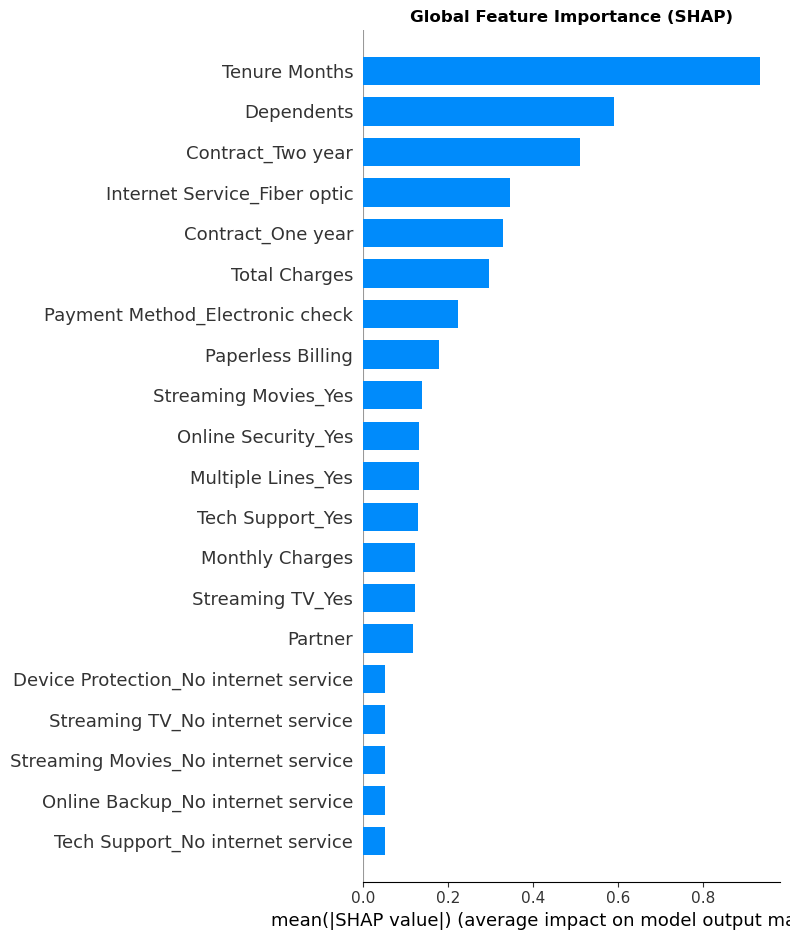

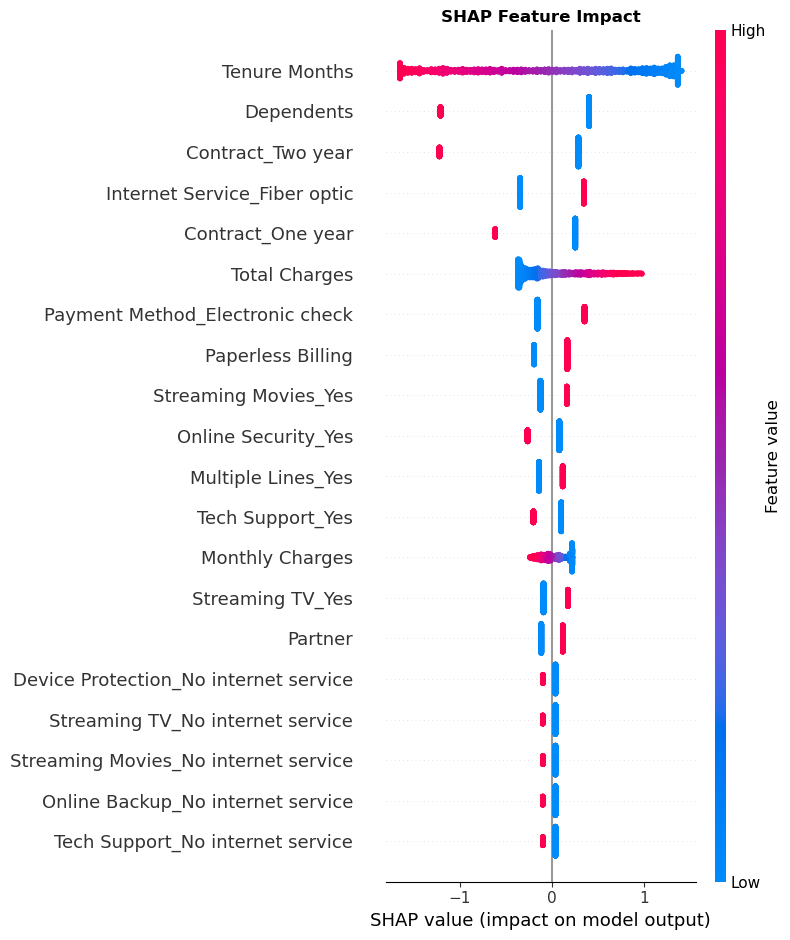


Sample customer churn explanation:


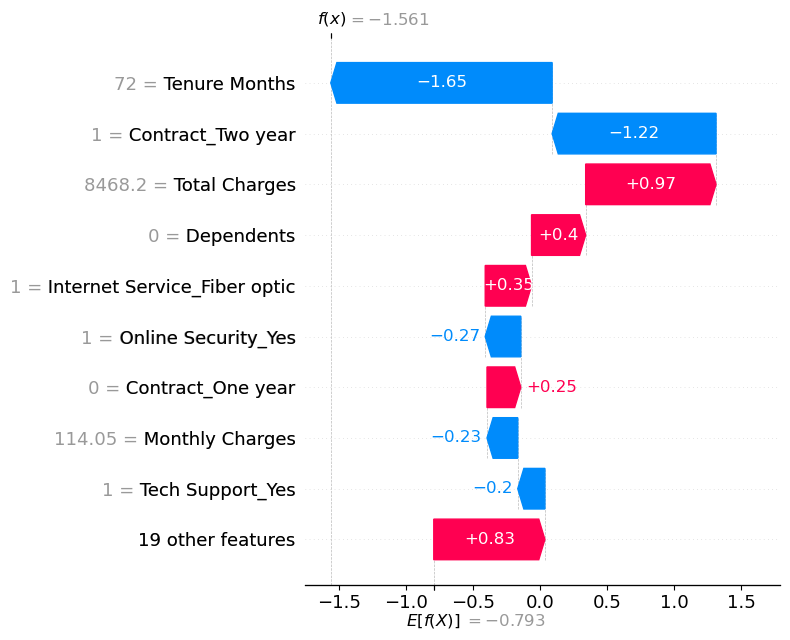

In [10]:
#SHAP
best_model = models_cw['Logistic Regression']

# SHAP explainer
explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer(X_test)

# Plot 1 — Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Impact direction (positive/negative effect on churn)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Single customer explanation
print("\nSample customer churn explanation:")
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.savefig('shap_customer.png', dpi=150, bbox_inches='tight')
plt.show()


Total at-risk customers: 3400 (48.3%)

Business Impact by Segment:
                   At_Risk_Customers  Monthly_Revenue_At_Risk  \
Segment_Name                                                    
Mid Value At-Risk               1350                 95875.70   
New At-Risk                     1426                 92096.35   
High Value Loyal                 586                 57417.90   
Budget Loyal                      38                  1822.50   

                   Avg_Churn_Probability  
Segment_Name                              
Mid Value At-Risk                   0.72  
New At-Risk                         0.71  
High Value Loyal                    0.62  
Budget Loyal                        0.50  

Retention Priority:
Segment                At Risk      Revenue at Risk      Action
Mid Value At-Risk      1350         ₹95,876         Targeted offers — largest group
New At-Risk            1426         ₹92,096         Onboarding improvement — stop early exits
High Value Loyal     

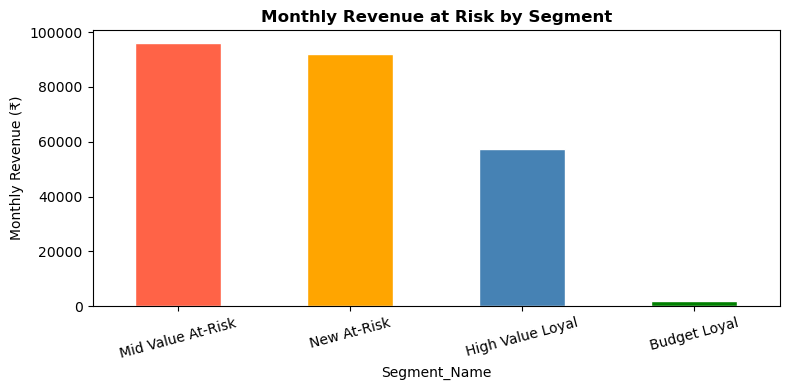

Risk Tier Distribution:
Risk_Tier
Safe           3643
High Risk      2373
Medium Risk    1027
Name: count, dtype: int64

Total High Risk: 2373 customers
Total Medium Risk: 1027 customers

High Risk Monthly Revenue at Risk: ₹183,817
Medium Risk Monthly Revenue at Risk: ₹63,395
Total Revenue at Risk: ₹247,212

High Risk Business Impact by Segment:
                   At_Risk_Customers  Monthly_Revenue_At_Risk  \
Segment_Name                                                    
Mid Value At-Risk               1021                 77877.85   
New At-Risk                     1044                 75930.00   
High Value Loyal                 303                 29745.60   
Budget Loyal                       5                   263.65   

                   Avg_Churn_Probability  
Segment_Name                              
Mid Value At-Risk                   0.79  
New At-Risk                         0.79  
High Value Loyal                    0.73  
Budget Loyal                        0.64  

Re

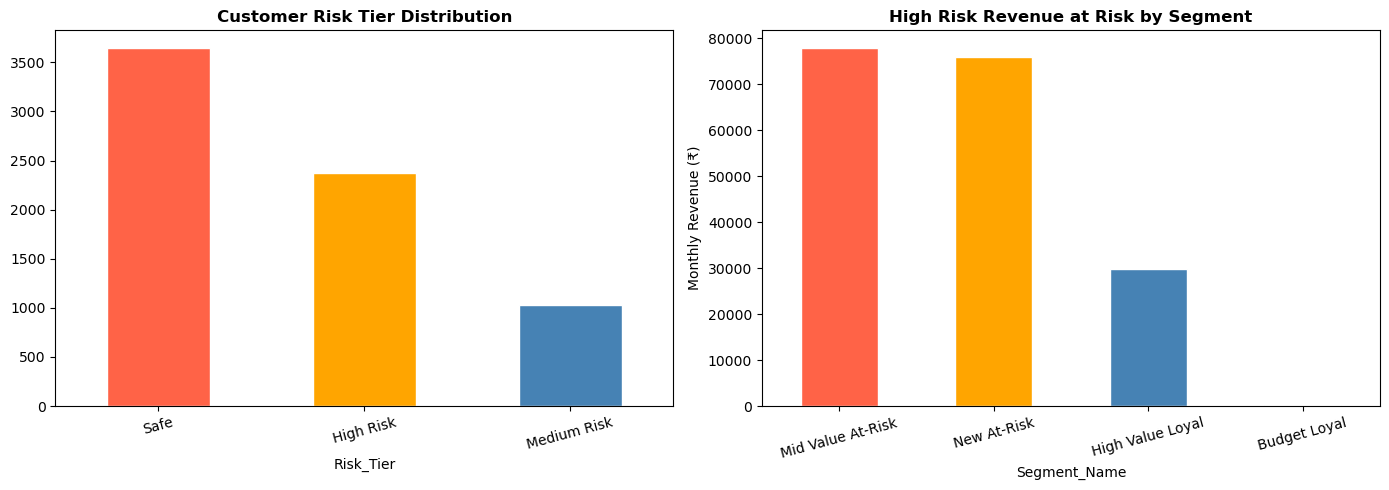

In [11]:
# Business Impact Analysis

# Get churn probabilities from best model (LR class_weight)
best_model = models_cw['Logistic Regression']
df_ml['Churn_Probability'] = best_model.predict_proba(X)[:, 1]
df_ml['Churn_Predicted'] = (df_ml['Churn_Probability'] >= 0.4).astype(int)

# At-risk customers
at_risk = df_ml[df_ml['Churn_Predicted'] == 1].copy()
print(f"Total at-risk customers: {len(at_risk)} ({len(at_risk)/len(df_ml)*100:.1f}%)")

# Revenue at risk per segment
df_ml['Monthly_Revenue'] = df['Monthly Charges']
at_risk['Monthly_Revenue'] = df.loc[at_risk.index, 'Monthly Charges']

segment_impact = at_risk.groupby('Segment_Name').agg(
    At_Risk_Customers=('Churn_Predicted', 'count'),
    Monthly_Revenue_At_Risk=('Monthly_Revenue', 'sum'),
    Avg_Churn_Probability=('Churn_Probability', 'mean')
).round(2).sort_values('Monthly_Revenue_At_Risk', ascending=False)

print("\nBusiness Impact by Segment:")
print(segment_impact)

# Priority action table
print("\nRetention Priority:")
print(f"{'Segment':<22} {'At Risk':<12} {'Revenue at Risk':<20} {'Action'}")
actions = {
    'High Value Loyal': 'Personal outreach — highest revenue impact',
    'New At-Risk': 'Onboarding improvement — stop early exits',
    'Mid Value At-Risk': 'Targeted offers — largest group',
    'Budget Loyal': 'Low priority — low churn rate'
}
for seg, row in segment_impact.iterrows():
    print(f"{seg:<22} {int(row['At_Risk_Customers']):<12} ₹{row['Monthly_Revenue_At_Risk']:,.0f}{'':<8} {actions.get(seg, '')}")

# Export at-risk customers for retention team
at_risk_export = df.loc[at_risk.index, ['Monthly Charges']].copy()
at_risk_export['Churn_Probability'] = at_risk['Churn_Probability'].values
at_risk_export['Segment'] = at_risk['Segment_Name'].values
at_risk_export = at_risk_export.sort_values('Churn_Probability', ascending=False)
at_risk_export.to_csv('at_risk_customers.csv', index=False)
print(f"\nExported {len(at_risk_export)} at-risk customers to at_risk_customers.csv")

# Visualize revenue at risk
plt.figure(figsize=(8, 4))
segment_impact['Monthly_Revenue_At_Risk'].plot(kind='bar', color=['tomato','orange','steelblue','green'], edgecolor='white')
plt.title('Monthly Revenue at Risk by Segment', fontweight='bold')
plt.ylabel('Monthly Revenue (₹)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()


# Business Impact Analysis (Tiered Risk)

# Get churn probabilities from best model (LR class_weight)
best_model = models_cw['Logistic Regression']
df_ml['Churn_Probability'] = best_model.predict_proba(X)[:, 1]

# Tiered risk levels
def risk_tier(prob):
    if prob >= 0.6:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Safe'

df_ml['Risk_Tier'] = df_ml['Churn_Probability'].apply(risk_tier)
df_ml['Monthly_Revenue'] = df['Monthly Charges']

# Summary
print("Risk Tier Distribution:")
print(df_ml['Risk_Tier'].value_counts())
print(f"\nTotal High Risk: {(df_ml['Risk_Tier']=='High Risk').sum()} customers")
print(f"Total Medium Risk: {(df_ml['Risk_Tier']=='Medium Risk').sum()} customers")

# Revenue at risk — High Risk only
high_risk = df_ml[df_ml['Risk_Tier'] == 'High Risk']
medium_risk = df_ml[df_ml['Risk_Tier'] == 'Medium Risk']

print(f"\nHigh Risk Monthly Revenue at Risk: ₹{high_risk['Monthly_Revenue'].sum():,.0f}")
print(f"Medium Risk Monthly Revenue at Risk: ₹{medium_risk['Monthly_Revenue'].sum():,.0f}")
print(f"Total Revenue at Risk: ₹{(high_risk['Monthly_Revenue'].sum() + medium_risk['Monthly_Revenue'].sum()):,.0f}")

# Segment breakdown — High Risk only
segment_impact = high_risk.groupby('Segment_Name').agg(
    At_Risk_Customers=('Risk_Tier', 'count'),
    Monthly_Revenue_At_Risk=('Monthly_Revenue', 'sum'),
    Avg_Churn_Probability=('Churn_Probability', 'mean')
).round(2).sort_values('Monthly_Revenue_At_Risk', ascending=False)

print("\nHigh Risk Business Impact by Segment:")
print(segment_impact)

# Priority action table
print("\nRetention Priority:")
print(f"{'Segment':<22} {'High Risk':<12} {'Revenue at Risk':<20} {'Action'}")
actions = {
    'High Value Loyal': 'Personal outreach — highest revenue impact',
    'New At-Risk': 'Onboarding improvement — stop early exits',
    'Mid Value At-Risk': 'Targeted offers — largest group',
    'Budget Loyal': 'Low priority — low churn rate'
}
for seg, row in segment_impact.iterrows():
    print(f"{seg:<22} {int(row['At_Risk_Customers']):<12} ₹{row['Monthly_Revenue_At_Risk']:,.0f}{'':>8} {actions.get(seg, '')}")

# Export tiered list
export = df.loc[df_ml.index, ['Monthly Charges']].copy()
export['Churn_Probability'] = df_ml['Churn_Probability'].values
export['Risk_Tier'] = df_ml['Risk_Tier'].values
export['Segment'] = df_ml['Segment_Name'].values
export = export.sort_values('Churn_Probability', ascending=False)
export.to_csv('customer_risk_tiers.csv', index=False)
print(f"\nExported {len(export)} customers with risk tiers to customer_risk_tiers.csv")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk tier distribution
df_ml['Risk_Tier'].value_counts().plot(kind='bar', ax=axes[0], 
    color=['tomato','orange','steelblue'], edgecolor='white')
axes[0].set_title('Customer Risk Tier Distribution', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

# Revenue at risk by segment
segment_impact['Monthly_Revenue_At_Risk'].plot(kind='bar', ax=axes[1],
    color=['tomato','orange','steelblue','green'], edgecolor='white')
axes[1].set_title('High Risk Revenue at Risk by Segment', fontweight='bold')
axes[1].set_ylabel('Monthly Revenue (₹)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.savefig('business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

Top 5 Peak Churn Months:
 Tenure Months  Churn_Rate_Pct  Customer_Count
             1       61.990212             613
             2       51.680672             238
             5       48.120301             133
             4       47.159091             176
             3       47.000000             200

6-Month Forecast (based on last 6 months avg):
Month 73: 7.0% predicted churn rate
Month 74: 7.0% predicted churn rate
Month 75: 7.0% predicted churn rate
Month 76: 7.0% predicted churn rate
Month 77: 7.0% predicted churn rate
Month 78: 7.0% predicted churn rate


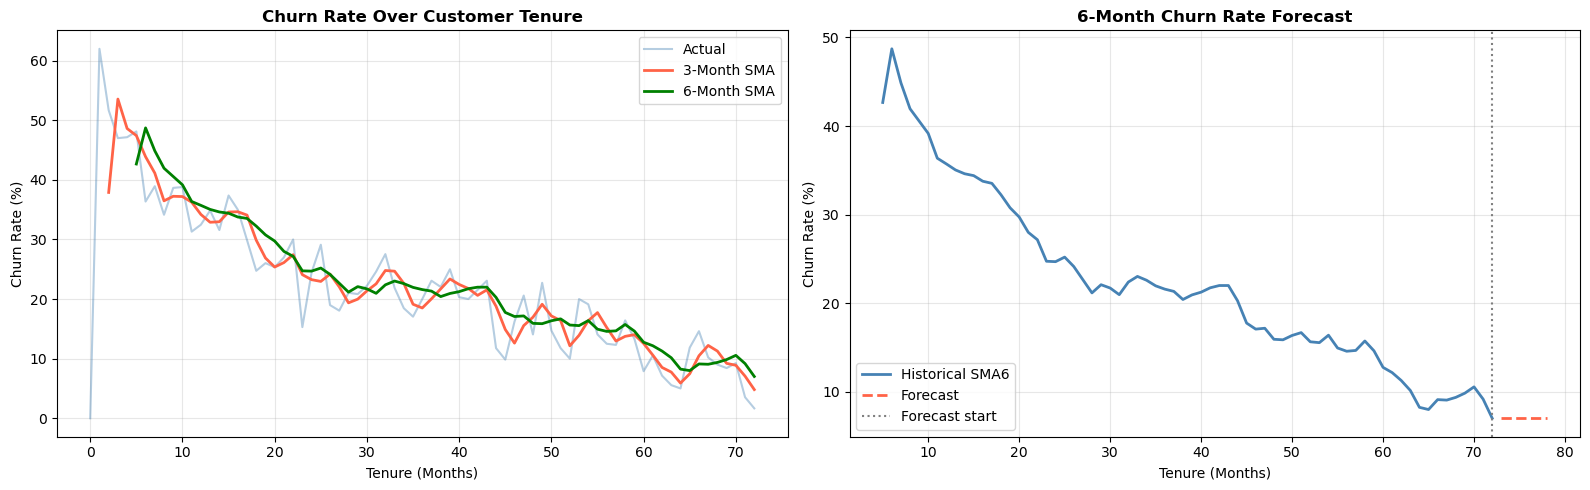

In [12]:
#  Churn Trend & Forecasting

# Churn rate by tenure month
trend = df.groupby('Tenure Months').agg(
    Churn_Rate=('Churn Value', 'mean'),
    Customer_Count=('Churn Value', 'count')
).reset_index()

trend['Churn_Rate_Pct'] = trend['Churn_Rate'] * 100

# Moving averages
trend['SMA_3'] = trend['Churn_Rate_Pct'].rolling(window=3).mean()
trend['SMA_6'] = trend['Churn_Rate_Pct'].rolling(window=6).mean()

# Peak churn months
peak_months = trend.nlargest(5, 'Churn_Rate_Pct')[['Tenure Months', 'Churn_Rate_Pct', 'Customer_Count']]
print("Top 5 Peak Churn Months:")
print(peak_months.to_string(index=False))

# Forecast next 6 months using last 6 months average
last_6_avg = trend['Churn_Rate_Pct'].tail(6).mean()
future_months = list(range(73, 79))
future_churn = [last_6_avg] * 6

print(f"\n6-Month Forecast (based on last 6 months avg):")
for m, c in zip(future_months, future_churn):
    print(f"Month {m}: {c:.1f}% predicted churn rate")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trend plot
axes[0].plot(trend['Tenure Months'], trend['Churn_Rate_Pct'], 
             alpha=0.4, color='steelblue', label='Actual')
axes[0].plot(trend['Tenure Months'], trend['SMA_3'], 
             color='tomato', linewidth=2, label='3-Month SMA')
axes[0].plot(trend['Tenure Months'], trend['SMA_6'], 
             color='green', linewidth=2, label='6-Month SMA')
axes[0].set_title('Churn Rate Over Customer Tenure', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Forecast plot
all_months = list(trend['Tenure Months']) + future_months
all_sma6 = list(trend['SMA_6']) + future_churn
axes[1].plot(trend['Tenure Months'], trend['SMA_6'], 
             color='steelblue', linewidth=2, label='Historical SMA6')
axes[1].plot(future_months, future_churn, 
             color='tomato', linewidth=2, linestyle='--', label='Forecast')
axes[1].axvline(x=72, color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
axes[1].set_title('6-Month Churn Rate Forecast', fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('churn_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:

# Create models directory
os.makedirs('models', exist_ok=True)

# Save best model
best_model = models_cw['Logistic Regression']
joblib.dump(best_model, 'models/lr_churn_model.pkl')

# Save scaler (needed for clustering in dashboard)
joblib.dump(scaler, 'models/kmeans_scaler.pkl')

# Save kmeans
joblib.dump(kmeans, 'models/kmeans_model.pkl')

# Save df_ml with all predictions
df_ml.to_csv('models/df_ml_final.csv', index=False)

# Save feature columns (dashboard needs exact column order)
feature_cols = X.columns.tolist()
joblib.dump(feature_cols, 'models/feature_cols.pkl')

# Save SHAP values
joblib.dump(shap_values, 'models/shap_values.pkl')

# Summary
print("Saved:")
print(f"  models/lr_churn_model.pkl")
print(f"  models/kmeans_scaler.pkl")
print(f"  models/kmeans_model.pkl")
print(f"  models/df_ml_final.csv")
print(f"  models/feature_cols.pkl")
print(f"  models/shap_values.pkl")
print(f"\ndf_ml shape: {df_ml.shape}")
print(f"Feature columns: {len(feature_cols)}")


Saved:
  models/lr_churn_model.pkl
  models/kmeans_scaler.pkl
  models/kmeans_model.pkl
  models/df_ml_final.csv
  models/feature_cols.pkl
  models/shap_values.pkl

df_ml shape: (7043, 35)
Feature columns: 28
